# 05 — Flipped Voltage Follower (FVF)

**Dataset:** `datasets/fvf/`

Topology: 2 NMOS
- M_main (input follower): G=VIN, D=Ib, S=VOUT
- M_fb (feedback): G=Ib, D=VOUT, S=GND

Nodes: `VIN VOUT Ib`

In [1]:
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, os.path.abspath('../../src/gelochip'))
import gelochip.gl as gl
gl.reload()  # pick up latest code without restarting kernel


2026-05-19 18:04:59.282 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active
2026-05-19 18:05:00.008 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/fvf.gds'


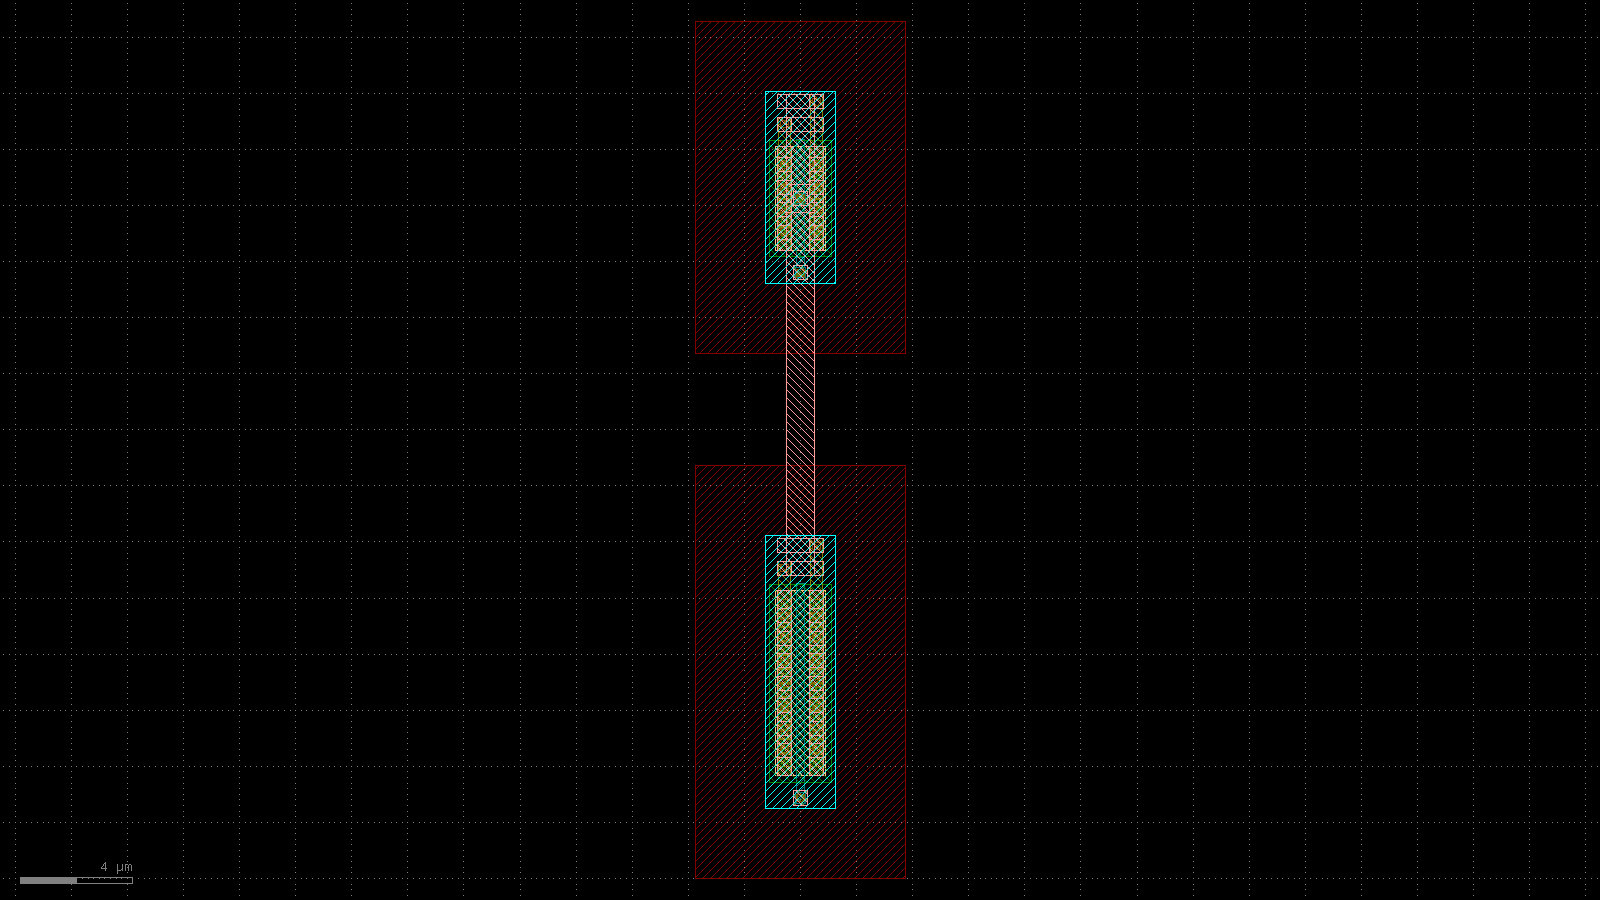

2026-05-19 18:05:00.167 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/gelo_dataset_optimized/FVF.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-19 18:05:00.433 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpoy3yznhc/FVF.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpimpyqqx_/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "FVF".
[INFO]: Loading FVF

Load

{'converged': False, 'error': 'no netlist'}

In [2]:
vin  = gl.Net('vin')
vout = gl.Net('vout')
ib   = gl.Net('ib')   # current bias node (external Ib current injected here)

m_main = gl.nmos(w=6.6, fingers=1, g=vin, d=ib,   s=vout)  # G=VIN, D=Ib, S=VOUT
m_fb   = gl.nmos(w=3.7, fingers=1, g=ib,  d=vout,  s=gl.gnd)  # G=Ib, D=VOUT, S=GND

chip = gl.build(m_main, m_fb, name='fvf')
chip.show()
chip.drc()
chip.sim()